# Module 22 — Scaling Intuitions: the calculator

This notebook is the working scaling-law calculator described in the README. It has no model loads and no network — just the arithmetic that governs every frontier run. It runs in milliseconds on CPU.

By the end you'll be able to take a compute budget, any compute budget, and read off the model size, the token count, the predicted loss, the wall-clock time, and the dollar cost — and watch your $50 course demo extrapolate twelve orders of magnitude into a frontier model on the same two lines of math.

In [1]:
import math
import matplotlib.pyplot as plt

from scaling import (
    training_flops, chinchilla_optimal, CHINCHILLA, ScalingLaw,
    cost_and_time, extrapolate, overtrain_savings,
    LADDER, ScalePoint, TOKENS_PER_PARAM, _si,
)

print("tokens-per-parameter rule:", TOKENS_PER_PARAM)

tokens-per-parameter rule: 20.0


## 1. The one equation: C ≈ 6ND

A training run over `D` tokens of a model with `N` parameters costs about `6·N·D` FLOPs. Let's check it reproduces the published compute figures for models we know.

In [2]:
models = [
    ("GPT-3 (175B)",      1.75e11, 3.0e11),
    ("Chinchilla (70B)",  7.0e10,  1.4e12),
    ("Llama 3 8B",        8.0e9,   15e12),
    ("Llama 3 70B",       7.0e10,  15e12),
]
print(f"{'model':20s} {'params':>10s} {'tokens':>10s} {'C = 6ND':>12s} {'tok/param':>10s}")
for name, n, d in models:
    c = training_flops(n, d)
    print(f"{name:20s} {_si(n):>10s} {_si(d):>10s} {_si(c)+'FLOPs':>12s} {d/n:>10.0f}")

print()
print("Chinchilla check: 6 x 70e9 x 1.4e12 =", f"{training_flops(7e10,1.4e12):.2e}",
      "FLOPs (the canonical ~5.9e23)")

model                    params     tokens      C = 6ND  tok/param
GPT-3 (175B)            175.00G    300.00G 315.00ZFLOPs          2
Chinchilla (70B)         70.00G      1.40T 588.00ZFLOPs         20
Llama 3 8B                8.00G     15.00T 720.00ZFLOPs       1875
Llama 3 70B              70.00G     15.00T   6.30YFLOPs        214

Chinchilla check: 6 x 70e9 x 1.4e12 = 5.88e+23 FLOPs (the canonical ~5.9e23)


Notice the `tok/param` column already tells a story: GPT-3 trained on **~2** tokens per parameter (wildly under-trained), Chinchilla on **20** (compute-optimal), Llama 3 8B on **~1,900** (deliberately over-trained for cheap inference). Same equation, three very different philosophies.

## 2. Compute-optimal allocation

Given a budget `C`, split it as `N_opt = √(C/120)`, `D_opt = 20·N_opt`. Let's tabulate across twelve orders of magnitude of compute.

In [3]:
budgets = [1e18, 1e20, 1e22, 5.88e23, 1e25, 1e26]
print(f"{'compute C':>14s} {'N_opt':>12s} {'D_opt':>12s}")
for c in budgets:
    a = chinchilla_optimal(c)
    print(f"{_si(c)+'FLOPs':>14s} {_si(a.n_params)+'p':>12s} {_si(a.n_tokens)+'t':>12s}")
print()
print("Sanity — feed it Chinchilla's compute:")
print("  ", chinchilla_optimal(5.88e23))

     compute C        N_opt        D_opt
    1.00EFLOPs      91.29Mp       1.83Gt
  100.00EFLOPs     912.87Mp      18.26Gt
   10.00ZFLOPs       9.13Gp     182.57Gt
  588.00ZFLOPs      70.00Gp       1.40Tt
   10.00YFLOPs     288.68Gp       5.77Tt
  100.00YFLOPs     912.87Gp      18.26Tt

Sanity — feed it Chinchilla's compute:
   C=588.00ZFLOPs  ->  N=70.00Gparams, D=1.40Ttokens (20 tok/param)


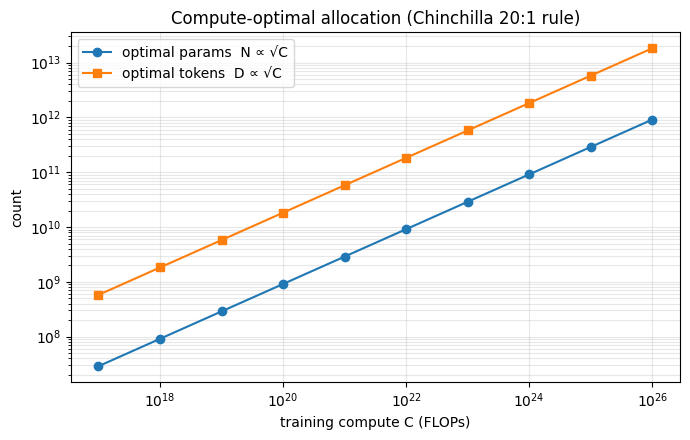

In [4]:
# The allocation curves: as compute grows, model and data grow in lockstep (both ~ C^0.5).
cs = [10**e for e in range(17, 27)]
ns = [chinchilla_optimal(c).n_params for c in cs]
ds = [chinchilla_optimal(c).n_tokens for c in cs]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(cs, ns, "o-", label="optimal params  N ∝ √C")
ax.loglog(cs, ds, "s-", label="optimal tokens  D ∝ √C")
ax.set_xlabel("training compute C (FLOPs)")
ax.set_ylabel("count")
ax.set_title("Compute-optimal allocation (Chinchilla 20:1 rule)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

### Where do real models sit?

The compute-optimal line says "20 tokens per parameter." Real models scatter around it on purpose — under-trained models (GPT-3 era) sit below, inference-optimized models (Llama 3) sit far above.

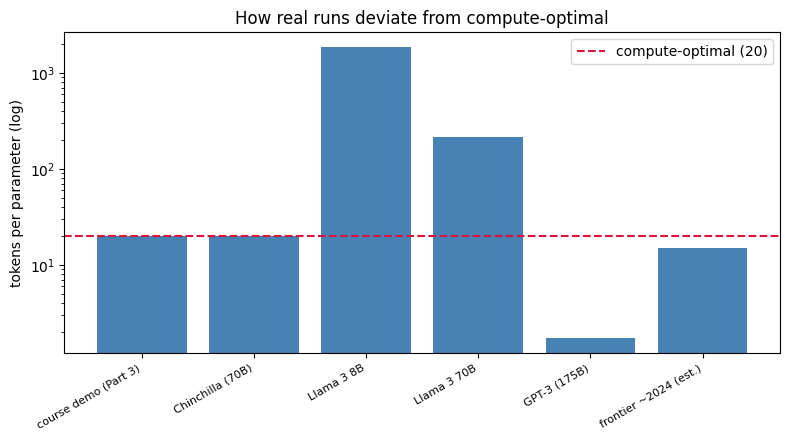

  course demo (Part 3)              20 tok/param  (~optimal)
  Chinchilla (70B)                  20 tok/param  (~optimal)
  Llama 3 8B                      1875 tok/param  (over-trained)
  Llama 3 70B                      214 tok/param  (over-trained)
  GPT-3 (175B)                       2 tok/param  (under-trained)
  frontier ~2024 (est.)             15 tok/param  (~optimal)


In [5]:
names = [p.name for p in LADDER]
tpp = [p.tokens_per_param for p in LADDER]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(range(len(LADDER)), tpp, color="steelblue")
ax.axhline(TOKENS_PER_PARAM, color="crimson", ls="--", label="compute-optimal (20)")
ax.set_yscale("log")
ax.set_xticks(range(len(LADDER)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("tokens per parameter (log)")
ax.set_title("How real runs deviate from compute-optimal")
ax.legend()
plt.tight_layout(); plt.show()

for p in LADDER:
    side = "under-trained" if p.tokens_per_param < 15 else ("over-trained" if p.tokens_per_param > 30 else "~optimal")
    print(f"  {p.name:28s} {p.tokens_per_param:7.0f} tok/param  ({side})")

## 3. Predicting loss before you spend a dollar

`L(N, D) = E + A/N^α + B/D^β`. Plot predicted loss against compute, when every budget is spent compute-optimally. The decline is a *power law* — slow, relentless, and (crucially) **smooth enough to extrapolate**.

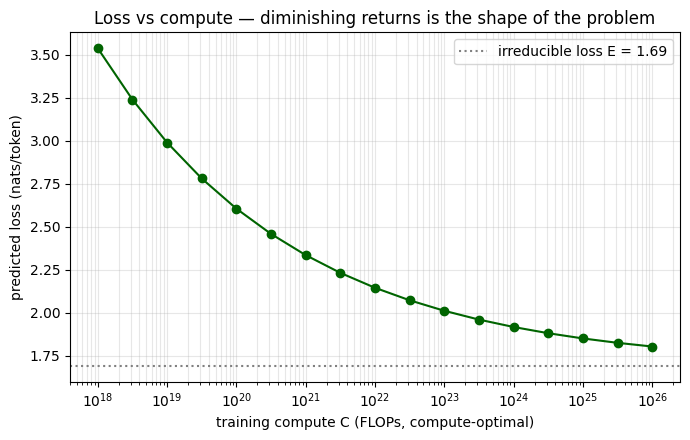

100x more compute buys you:
  loss 2.146 -> 1.918  (a drop of 0.228 nats for 100x the spend)


In [6]:
cs = [10**(e/2) for e in range(36, 53)]   # 1e18 .. 1e26
losses = [CHINCHILLA.loss_at_optimal(c) for c in cs]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(cs, losses, "o-", color="darkgreen")
ax.axhline(CHINCHILLA.E, color="gray", ls=":", label=f"irreducible loss E = {CHINCHILLA.E}")
ax.set_xlabel("training compute C (FLOPs, compute-optimal)")
ax.set_ylabel("predicted loss (nats/token)")
ax.set_title("Loss vs compute — diminishing returns is the shape of the problem")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print("100x more compute buys you:")
lo = CHINCHILLA.loss_at_optimal(1e22)
hi = CHINCHILLA.loss_at_optimal(1e24)
print(f"  loss {lo:.3f} -> {hi:.3f}  (a drop of {lo-hi:.3f} nats for 100x the spend)")

The exponents are small (`α≈0.34`, `β≈0.28`) — that's *why* frontier progress is so expensive. Every increment of quality costs an order of magnitude more compute. But because the curve is smooth, a lab can fit it on cheap runs and **predict the loss of a run 10,000× larger.** That predictability is the entire reason anyone is willing to spend $50M on a single training run.

## 4. From your $50 run to a $50M run

The same `chinchilla_optimal` + `cost_and_time` carry you across the whole ladder. Here's every rung, with a cost estimate at a realistic MFU.

In [7]:
print(f"{'run':28s} {'params':>9s} {'tokens':>9s} {'compute':>11s} {'~cost (H100)':>14s}")
for p in LADDER:
    est = cost_and_time(p.flops, gpu="H100", n_gpus=1024, mfu=0.4)
    print(f"{p.name:28s} {_si(p.n_params)+'p':>9s} {_si(p.n_tokens)+'t':>9s} "
          f"{_si(p.flops)+'F':>11s} {'$'+format(est.cost_usd, ',.0f'):>14s}")

run                             params    tokens     compute   ~cost (H100)
course demo (Part 3)          150.00Mp    3.00Gt      2.70EF             $5
Chinchilla (70B)               70.00Gp    1.40Tt    588.00ZF     $1,031,145
Llama 3 8B                      8.00Gp   15.00Tt    720.00ZF     $1,262,626
Llama 3 70B                    70.00Gp   15.00Tt      6.30YF    $11,047,980
GPT-3 (175B)                  175.00Gp  300.00Gt    315.00ZF       $552,399
frontier ~2024 (est.)           1.00Tp   15.00Tt     90.00YF   $157,828,283


In [8]:
# Take your Part 3 demo and scale its compute by a million. What would you train?
demo = LADDER[0]
print("Your course demo:", demo.name)
print("   ", f"{_si(demo.n_params)} params, {_si(demo.n_tokens)} tokens, {_si(demo.flops)} FLOPs")
print()
for mult in [1e3, 1e6, 1e8]:
    a = extrapolate(demo, mult)
    print(f"  x{_si(mult):>7s} compute -> {_si(a.n_params)} params, {_si(a.n_tokens)} tokens")
print()
print("A million times your demo's compute, spent optimally, is a ~150B-param frontier run —")
print("derived from your toy run with a single square root.")

Your course demo: course demo (Part 3)
    150.00M params, 3.00G tokens, 2.70E FLOPs

  x  1.00k compute -> 4.74G params, 94.87G tokens
  x  1.00M compute -> 150.00G params, 3.00T tokens
  x100.00M compute -> 1.50T params, 30.00T tokens

A million times your demo's compute, spent optimally, is a ~150B-param frontier run —
derived from your toy run with a single square root.


## 5. The over-training trade: train smaller, serve cheaper

Chinchilla-optimal minimizes *training* compute. But you pay for *inference* every time a user sends a request. So if you'll serve a model a lot, it pays to train a **smaller** model **past** its optimal point — more training cost now, cheaper inference forever. This is the Llama 3 8B decision.

In [9]:
# A 70B trained compute-optimally vs an 8B trained long enough to match its loss.
s = overtrain_savings(n_params_optimal=7e10, n_params_smaller=8e9)
print(f"Target loss (70B compute-optimal): {s['target_loss']:.3f}")
print(f"  70B needs {_si(s['tokens_big'])} tokens (the optimal 20:1 point)")
print(f"  8B  needs {_si(s['tokens_small'])} tokens to MATCH that loss  "
      f"({s['tokens_small']/8e9:.0f} tok/param)")
print()
print(f"  Training cost: {s['extra_train_cost_x']:.1f}x more for the 8B")
print(f"  Inference cost: {1/s['inference_flops_ratio']:.1f}x CHEAPER, on every request, forever")
print()
print("If you serve billions of requests, paying ~2x training to save ~9x inference")
print("is the deal of the decade. That's why Llama 3 8B saw ~15T tokens.")

Target loss (70B compute-optimal): 1.937
  70B needs 1.40T tokens (the optimal 20:1 point)
  8B  needs 25.87T tokens to MATCH that loss  (3234 tok/param)

  Training cost: 2.1x more for the 8B
  Inference cost: 8.8x CHEAPER, on every request, forever

If you serve billions of requests, paying ~2x training to save ~9x inference
is the deal of the decade. That's why Llama 3 8B saw ~15T tokens.


## 6. Cost and wall-clock

FLOPs are free on paper. The bill comes from realized throughput (peak GPU FLOP/s × MFU) and price-per-hour. The gap between peak and realized — MFU — is where Part 3's efficiency lessons cash out as millions of dollars.

In [10]:
# One frontier-scale run, on different fleets and MFUs.
flops = 1e25
print(f"Spending {_si(flops)} FLOPs:")
for gpu, n, mfu in [("A100", 2048, 0.35), ("H100", 1024, 0.40), ("H100", 1024, 0.50), ("B200", 512, 0.45)]:
    est = cost_and_time(flops, gpu=gpu, n_gpus=n, mfu=mfu)
    print(f"  {n:>4d}x{gpu} @ MFU {mfu:.0%}:  {est.wall_clock_hours/24:6.1f} days, "
          f"${est.cost_usd:,.0f}")
print()
print("Same FLOPs — raising MFU from 40% to 50% on the H100 fleet saves real money")
print("and weeks of wall-clock. That delta is a full-time job at a frontier lab.")

Spending 10.00Y FLOPs:
  2048xA100 @ MFU 35%:   517.5 days, $38,156,288
  1024xH100 @ MFU 40%:   285.4 days, $17,536,476
  1024xH100 @ MFU 50%:   228.3 days, $14,029,181
   512xB200 @ MFU 45%:   223.3 days, $13,717,421

Same FLOPs — raising MFU from 40% to 50% on the H100 fleet saves real money
and weeks of wall-clock. That delta is a full-time job at a frontier lab.


## That's the course

You started not knowing what a token was. You've now built a tokenizer, an attention block, a full transformer, a pretraining loop and data pipeline, continual pretraining, the entire post-training stack, and an evaluation harness — and in this module you've done the arithmetic that governs the runs a thousand times bigger.

The gap between you and a frontier engineer is now mostly **evidence**: runs you've done, results you've measured, things you've shipped. The README's project list is where to go next. Go make some.